# **4. Unsupervised Machine Learning (IBM Machine Learning)**

**Dataset:** https://www.kaggle.com/datasets/ryanholbrook/fe-course-data/data

**Objective:**
To create a clustering of a grouped playlist from all spotify listed songs from 1957 to 2020, using various unsupervised learning methods.

# **0. Import Libraries and Data**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score
)
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from collections import Counter

In [2]:
PALETTE   = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
BG        = "#F8F8F8"
ACCENT    = "#2C2C2A"
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({"figure.facecolor": BG, "axes.facecolor": BG,
                     "axes.edgecolor": "#CCCCCC", "grid.color": "#E0E0E0"})

In [5]:
df = pd.read_csv('/kaggle/input/datasets/ryanholbrook/fe-course-data/spotify.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

In [6]:

    display(df['track_album_release_date'].value_counts())
    print()

track_album_release_date
2020-01-10    270
2019-11-22    244
2019-12-06    235
2019-12-13    220
2013-01-01    219
             ... 
2019-03-05      1
2014-04-18      1
2013-06-29      1
2017-10-28      1
2016-05-19      1
Name: count, Length: 4530, dtype: int64

In [7]:
df['track_album_release_date'].max() , df['track_album_release_date'].min()

('2020-01-29', '1957-01-01')

In [5]:
df.columns

Index(['track_id', 'track_name', 'track_artist', 'track_popularity',
       'track_album_id', 'track_album_name', 'track_album_release_date',
       'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_ms'],
      dtype='object')

In [8]:
len(df.duplicated())

32833

In [4]:
df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


# **1. Data Cleaning**

In [5]:
FEATURE_COLS = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "duration_ms"
]

before = len(df)
df_clean = df.drop_duplicates(subset=["track_id"]).copy()
print(f"  Duplicates removed  : {before - len(df_clean)}")

  Duplicates removed  : 4477


In [6]:
df_clean = df_clean.dropna(subset=FEATURE_COLS)
print(f"  Rows after cleaning : {len(df_clean)}")
print(f"  Features used       : {FEATURE_COLS}\n")

  Rows after cleaning : 28356
  Features used       : ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']



# **2. Feature Engineering**

In [7]:
df_clean["duration_min"] = df_clean["duration_ms"] / 60_000

df_clean["energy_acoustic_ratio"] = (
    df_clean["energy"] / (df_clean["acousticness"] + 1e-6)
).clip(upper=50)

df_clean["dance_valence"] = (
    df_clean["danceability"] * df_clean["valence"]
)

df_clean["live_speech"] = (
    df_clean["liveness"] * df_clean["speechiness"]
)

ENGINEERED = ["duration_min", "energy_acoustic_ratio",
              "dance_valence", "live_speech"]
ALL_FEATURES = FEATURE_COLS + ENGINEERED
print(f"  Engineered features : {ENGINEERED}\n")

  Engineered features : ['duration_min', 'energy_acoustic_ratio', 'dance_valence', 'live_speech']



# **3. Exploratory Data Analysis**

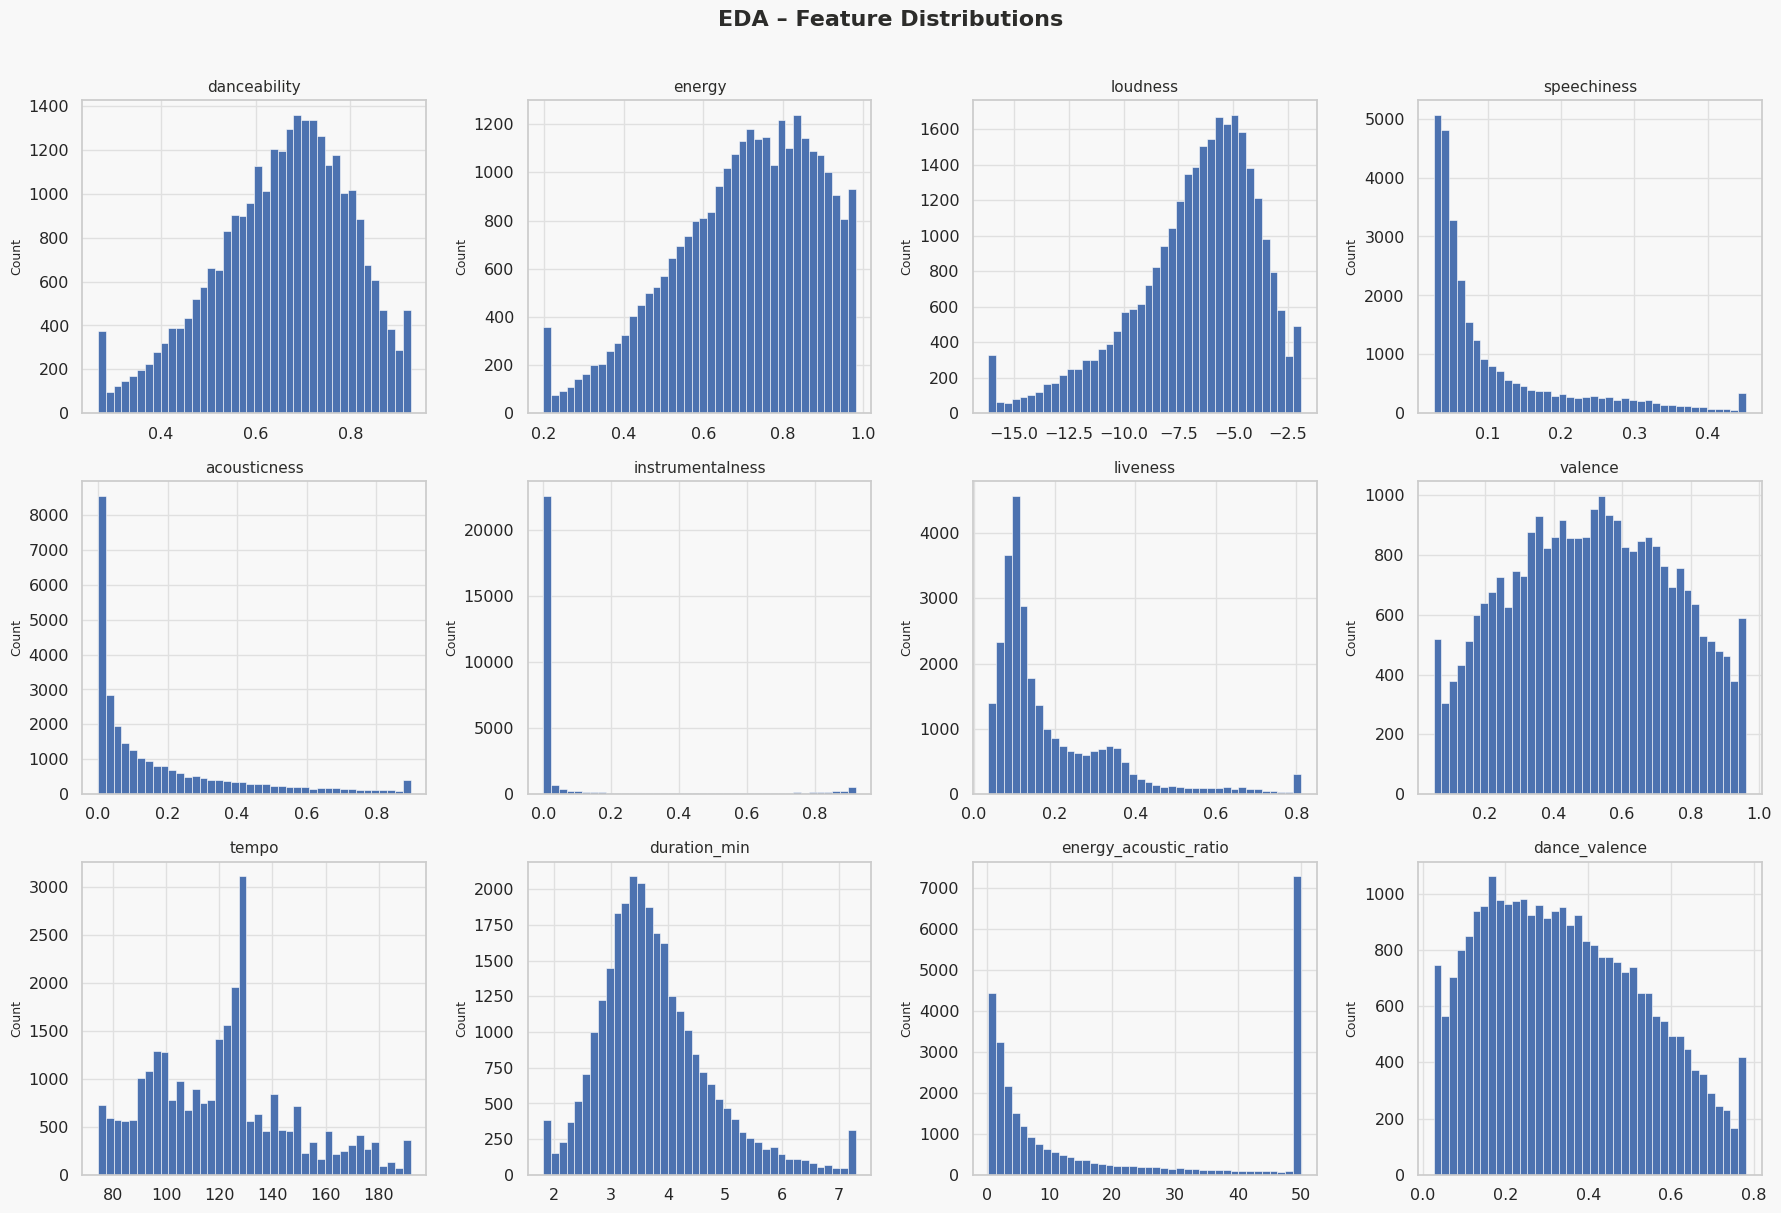

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle("EDA – Feature Distributions", fontsize=16, fontweight="bold",
             color=ACCENT, y=1.01)

base_features = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence",
    "tempo", "duration_min", "energy_acoustic_ratio", "dance_valence"
]

for ax, feat in zip(axes.flat, base_features):
    ax.hist(df_clean[feat].clip(
        lower=df_clean[feat].quantile(0.01),
        upper=df_clean[feat].quantile(0.99)
    ), bins=40, color=PALETTE[0], edgecolor="white", linewidth=0.4)
    ax.set_title(feat, fontsize=11, color=ACCENT)
    ax.set_xlabel("")
    ax.set_ylabel("Count", fontsize=9)

plt.tight_layout()
plt.show()

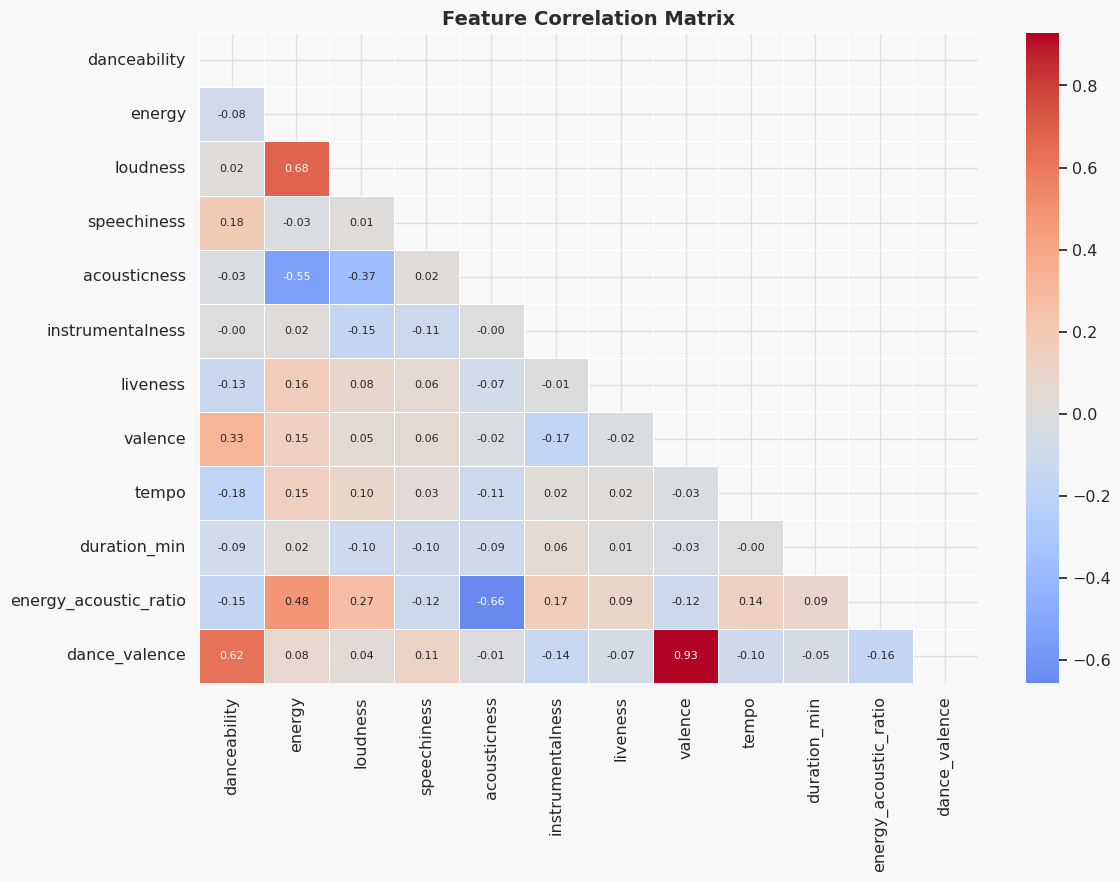

In [9]:
fig, ax = plt.subplots(figsize=(12, 9))
corr = df_clean[base_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.4, ax=ax, annot_kws={"size": 8})
ax.set_title("Feature Correlation Matrix", fontsize=14,
             fontweight="bold", color=ACCENT)
plt.tight_layout()
plt.show()

# **4. Preprocessing: Data Scaling & PCA**

In [10]:
X = df_clean[ALL_FEATURES].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components = int(np.searchsorted(cum_var, 0.95)) + 1
print(f"  Components for 95% variance : {n_components}")

  Components for 95% variance : 9


In [12]:
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)

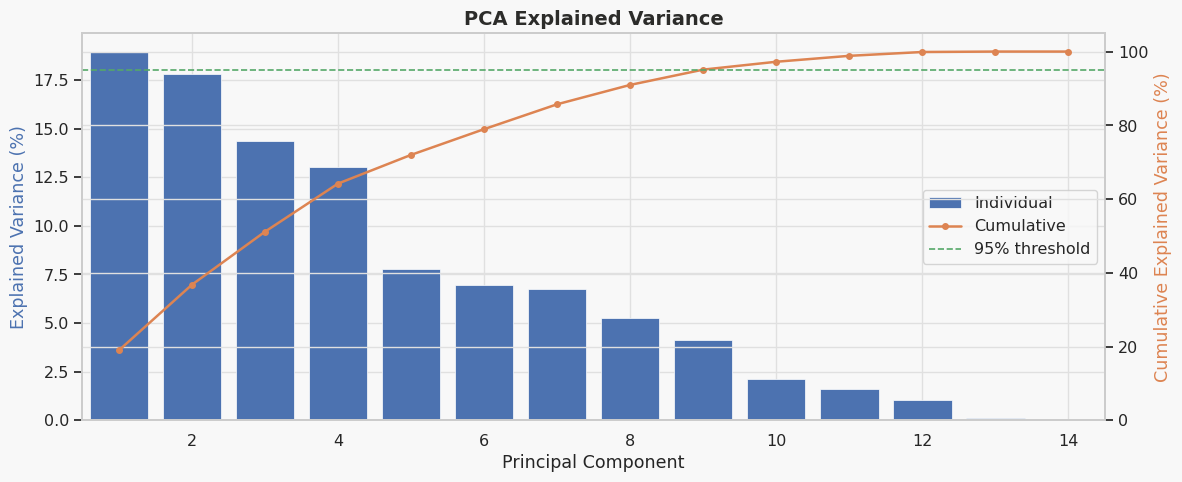

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
evr = pca_full.explained_variance_ratio_ * 100
bars = ax.bar(range(1, len(evr) + 1), evr, color=PALETTE[0],
              edgecolor="white", linewidth=0.5, label="Individual")
ax2 = ax.twinx()
ax2.plot(range(1, len(cum_var) + 1), cum_var * 100, color=PALETTE[1],
         marker="o", markersize=4, linewidth=1.8, label="Cumulative")
ax2.axhline(95, color=PALETTE[2], linestyle="--", linewidth=1.2,
            label="95% threshold")
ax2.set_ylim(0, 105)
ax2.set_ylabel("Cumulative Explained Variance (%)", color=PALETTE[1])

ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance (%)", color=PALETTE[0])
ax.set_title("PCA Explained Variance", fontsize=14,
             fontweight="bold", color=ACCENT)
ax.set_xlim(0.5, min(len(evr), 16) + 0.5)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="center right")

plt.tight_layout()
plt.show()

In [14]:
pca2 = PCA(n_components=2, random_state=42)
X_2d = pca2.fit_transform(X_scaled)

# **5. Optimal K Selection (Elbow + Silhouette)**

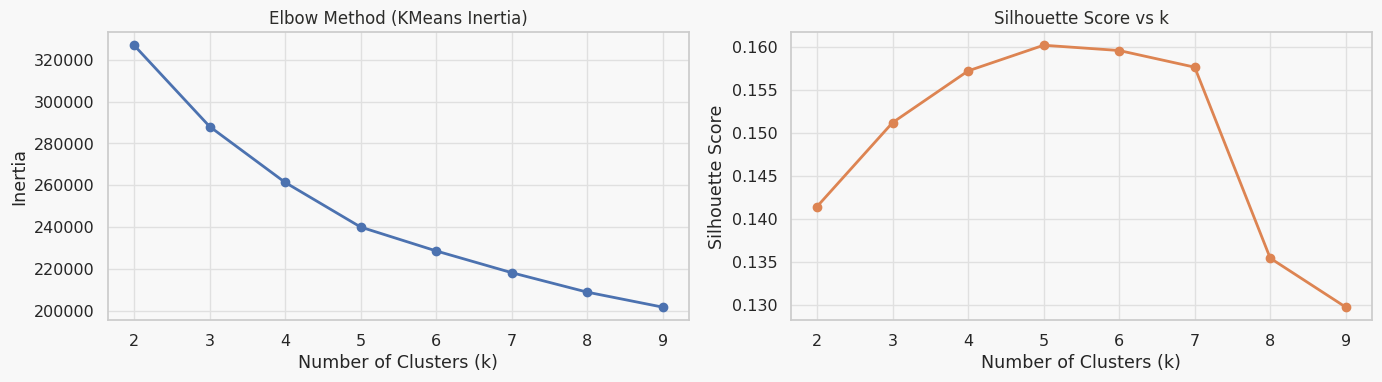

In [15]:
K_RANGE = range(2, 10)
inertias, sil_scores = [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels, sample_size=5000,
                                       random_state=42))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(list(K_RANGE), inertias, marker="o", color=PALETTE[0], linewidth=2)
ax1.set_title("Elbow Method (KMeans Inertia)", fontsize=12, color=ACCENT)
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia")

ax2.plot(list(K_RANGE), sil_scores, marker="o", color=PALETTE[1], linewidth=2)
ax2.set_title("Silhouette Score vs k", fontsize=12, color=ACCENT)
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

In [16]:
BEST_K = list(K_RANGE)[np.argmax(sil_scores)]
print(f"  Best k (max silhouette) : {BEST_K}\n")

  Best k (max silhouette) : 5



# **6. Train All Models**

In [17]:
#Kmeans
kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=20)
km_labels = kmeans.fit_predict(X_pca)

#GMM
gmm = GaussianMixture(n_components=BEST_K, covariance_type="full",
                      random_state=42, max_iter=300)
gmm.fit(X_pca)
gmm_labels = gmm.predict(X_pca)


In [19]:
# Random Forest Proximity Matrix + Hierarchical
rf = RandomForestClassifier(n_estimators=150, random_state=42,
                             n_jobs=-1, max_depth=12)
rf.fit(X_pca, km_labels)

leaf_ids = rf.apply(X_pca)        


N = len(X_pca)
CHUNK = 2000
proximity = np.zeros((N, N), dtype=np.float32)

for i in range(0, N, CHUNK):
    end_i = min(i + CHUNK, N)
    for j in range(0, N, CHUNK):
        end_j = min(j + CHUNK, N)
        
        
        A = leaf_ids[i:end_i]   
        B = leaf_ids[j:end_j]    
        
        prox_block = np.mean(
            A[:, np.newaxis, :] == B[np.newaxis, :, :], axis=2
        )
        
        proximity[i:end_i, j:end_j] = prox_block.astype(np.float32)


distance_matrix = 1.0 - proximity
np.fill_diagonal(distance_matrix, 0)

rf_hier = AgglomerativeClustering(
    n_clusters=BEST_K, metric="precomputed", linkage="average"
)
rf_labels = rf_hier.fit_predict(distance_matrix)

# **7. Evaluation Matrix**

In [21]:
def evaluate(labels, X):
    return {
        "Silhouette":          round(silhouette_score(X, labels,
                                     sample_size=5000, random_state=42), 4),
        "Davies-Bouldin":      round(davies_bouldin_score(X, labels), 4),
        "Calinski-Harabasz":   round(calinski_harabasz_score(X, labels), 2),
    }

results = {
    "K-Means":   evaluate(km_labels,  X_pca),
    "GMM":       evaluate(gmm_labels, X_pca),
    "RF+Hier":   evaluate(rf_labels,  X_pca),
}
eval_df = pd.DataFrame(results).T
print(eval_df.to_string())

         Silhouette  Davies-Bouldin  Calinski-Harabasz
K-Means      0.1603          1.6376            4062.53
GMM          0.0441          3.3826            1475.29
RF+Hier      0.1570          1.6593            3966.13


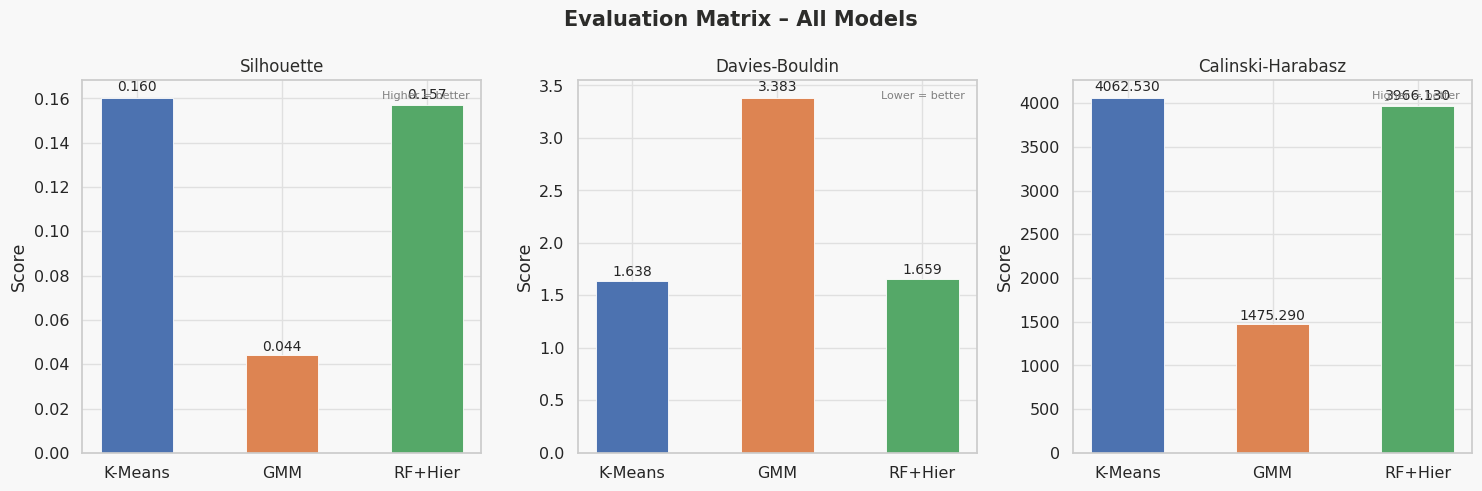

In [22]:
metrics   = ["Silhouette", "Davies-Bouldin", "Calinski-Harabasz"]
models    = list(results.keys())
n_metrics = len(metrics)

fig, axes = plt.subplots(1, n_metrics, figsize=(15, 5))
fig.suptitle("Evaluation Matrix – All Models", fontsize=15,
             fontweight="bold", color=ACCENT)

for ax, metric in zip(axes, metrics):
    vals   = [results[m][metric] for m in models]
    colors = [PALETTE[i] for i in range(len(models))]
    bars   = ax.bar(models, vals, color=colors, edgecolor="white",
                    linewidth=0.6, width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=10)
    ax.set_title(metric, fontsize=12, color=ACCENT)
    ax.set_ylabel("Score")
    note = ("Higher = better" if metric != "Davies-Bouldin"
            else "Lower = better")
    ax.text(0.97, 0.97, note, transform=ax.transAxes, fontsize=8,
            ha="right", va="top", color="gray")

plt.tight_layout()
plt.show()

In [23]:
sil_rank = np.argsort([-results[m]["Silhouette"]    for m in models])
db_rank  = np.argsort([ results[m]["Davies-Bouldin"] for m in models])
ch_rank  = np.argsort([-results[m]["Calinski-Harabasz"] for m in models])

rank_sum = {m: 0 for m in models}
for r_arr in [sil_rank, db_rank, ch_rank]:
    for rank, idx in enumerate(r_arr):
        rank_sum[models[idx]] += rank

BEST_MODEL_NAME = min(rank_sum, key=rank_sum.get)
best_labels_map = {"K-Means": km_labels, "GMM": gmm_labels, "RF+Hier": rf_labels}
BEST_LABELS = best_labels_map[BEST_MODEL_NAME]
print(f"  Best model: {BEST_MODEL_NAME}  (lowest aggregate rank)\n")


  Best model: K-Means  (lowest aggregate rank)



# **8. Best Model: Side-By-Side Cluster Visualisation**

In [24]:
df_clean["cluster"] = BEST_LABELS

cluster_colors = {i: PALETTE[i % len(PALETTE)] for i in range(BEST_K)}


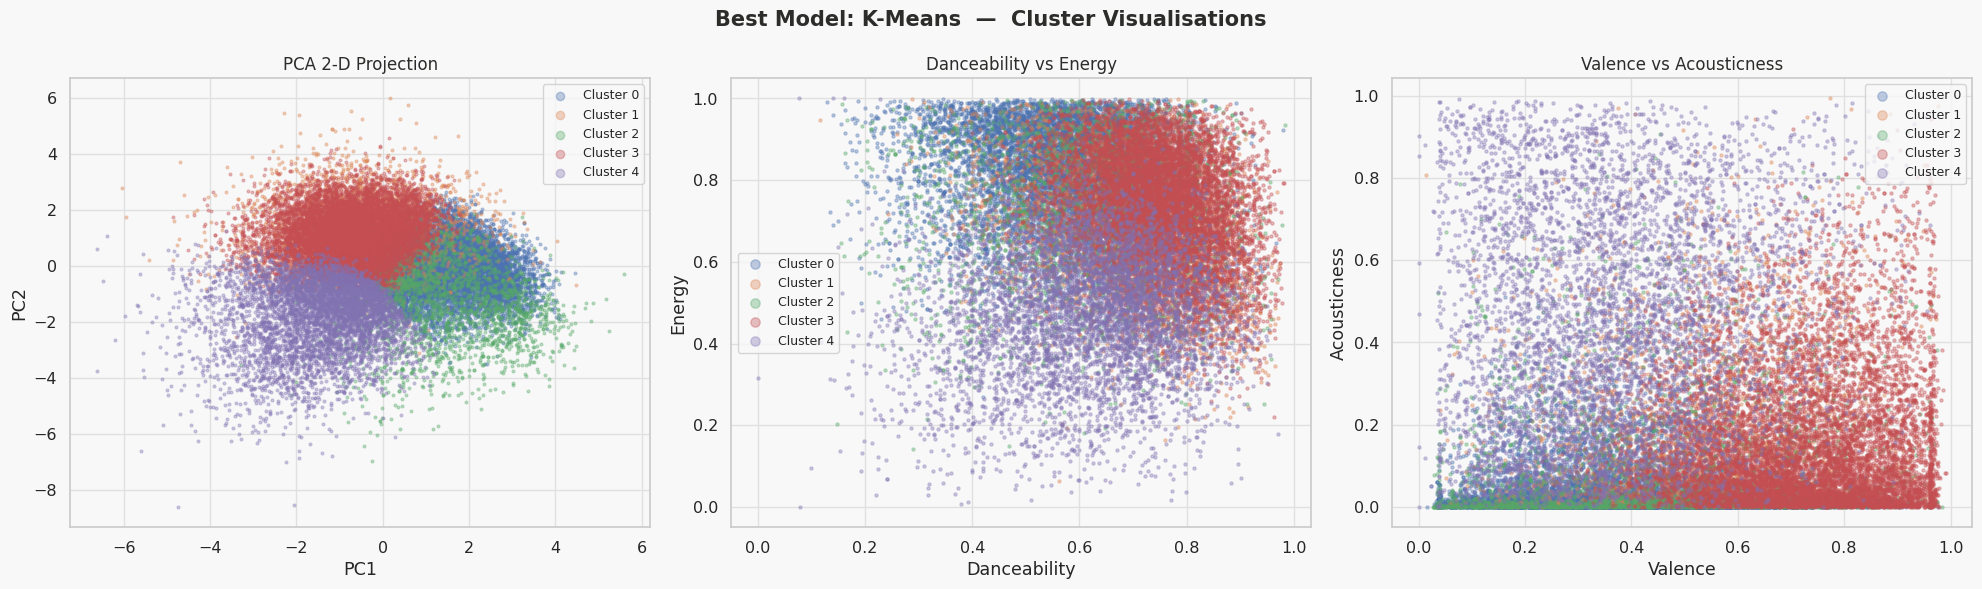

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(f"Best Model: {BEST_MODEL_NAME}  —  Cluster Visualisations",
             fontsize=15, fontweight="bold", color=ACCENT)

ax = axes[0]
for cl in sorted(df_clean["cluster"].unique()):
    mask = df_clean["cluster"] == cl
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=cluster_colors[cl], s=4, alpha=0.35,
               label=f"Cluster {cl}", rasterized=True)
ax.set_title("PCA 2-D Projection", fontsize=12, color=ACCENT)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(markerscale=3, fontsize=9)

ax = axes[1]
for cl in sorted(df_clean["cluster"].unique()):
    mask = df_clean["cluster"] == cl
    ax.scatter(df_clean.loc[mask, "danceability"],
               df_clean.loc[mask, "energy"],
               c=cluster_colors[cl], s=5, alpha=0.35,
               label=f"Cluster {cl}", rasterized=True)
ax.set_title("Danceability vs Energy", fontsize=12, color=ACCENT)
ax.set_xlabel("Danceability"); ax.set_ylabel("Energy")
ax.legend(markerscale=3, fontsize=9)

ax = axes[2]
for cl in sorted(df_clean["cluster"].unique()):
    mask = df_clean["cluster"] == cl
    ax.scatter(df_clean.loc[mask, "valence"],
               df_clean.loc[mask, "acousticness"],
               c=cluster_colors[cl], s=5, alpha=0.35,
               label=f"Cluster {cl}", rasterized=True)
ax.set_title("Valence vs Acousticness", fontsize=12, color=ACCENT)
ax.set_xlabel("Valence"); ax.set_ylabel("Acousticness")
ax.legend(markerscale=3, fontsize=9)

plt.tight_layout()
plt.show()

# **9. Interpretation of Best Model's Clusters**

In [26]:
INTERP_FEATURES = [
    "danceability", "energy", "loudness", "acousticness",
    "instrumentalness", "valence", "tempo",
    "speechiness", "liveness", "duration_min"
]

cluster_profiles = df_clean.groupby("cluster")[INTERP_FEATURES].mean()
print("\nCluster Mean Profiles:")
print(cluster_profiles.round(3).to_string())



Cluster Mean Profiles:
         danceability  energy  loudness  acousticness  instrumentalness  valence    tempo  speechiness  liveness  duration_min
cluster                                                                                                                       
0               0.570   0.816    -5.209         0.037             0.111    0.379  129.039        0.076     0.215         3.527
1               0.691   0.691    -6.783         0.178             0.024    0.542  122.038        0.326     0.322         3.627
2               0.633   0.707    -7.957         0.100             0.250    0.457  122.759        0.077     0.184         5.899
3               0.746   0.728    -6.259         0.163             0.034    0.719  116.904        0.096     0.155         3.584
4               0.614   0.467    -9.698         0.454             0.114    0.366  114.031        0.082     0.153         3.529


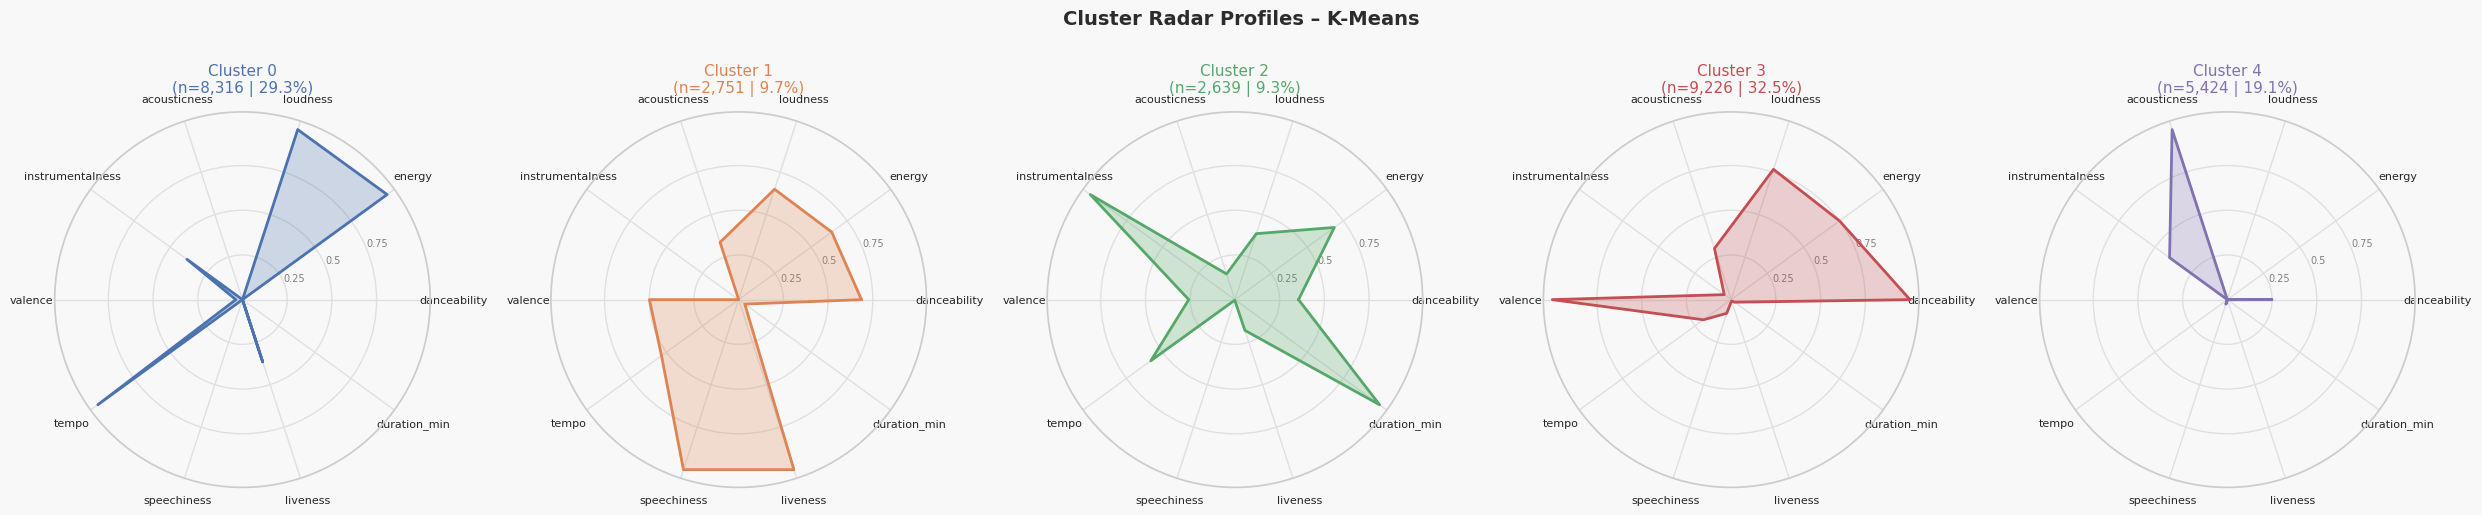

In [27]:
from matplotlib.patches import FancyArrowPatch

n_feat   = len(INTERP_FEATURES)
angles   = np.linspace(0, 2 * np.pi, n_feat, endpoint=False).tolist()
angles  += angles[:1]

norm_profiles = (cluster_profiles - cluster_profiles.min()) / (
    cluster_profiles.max() - cluster_profiles.min() + 1e-9
)

fig, axes_r = plt.subplots(1, BEST_K,
                            figsize=(5 * BEST_K, 5),
                            subplot_kw=dict(polar=True))
fig.suptitle(f"Cluster Radar Profiles – {BEST_MODEL_NAME}",
             fontsize=14, fontweight="bold", color=ACCENT, y=1.02)

if BEST_K == 1:
    axes_r = [axes_r]

for cl, ax in zip(sorted(df_clean["cluster"].unique()), axes_r):
    values = norm_profiles.loc[cl].tolist() + [norm_profiles.loc[cl].tolist()[0]]
    ax.plot(angles, values, color=cluster_colors[cl], linewidth=2)
    ax.fill(angles, values, color=cluster_colors[cl], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(INTERP_FEATURES, size=8)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(["0.25", "0.5", "0.75"], size=7, color="gray")
    n = int((df_clean["cluster"] == cl).sum())
    pct = n / len(df_clean) * 100
    ax.set_title(f"Cluster {cl}\n(n={n:,} | {pct:.1f}%)",
                 size=11, color=cluster_colors[cl], pad=14)

plt.tight_layout()
plt.show()

In [28]:
if "playlist_genre" in df_clean.columns:
    print("\n  Top genre per cluster:")
    for cl in sorted(df_clean["cluster"].unique()):
        genre_counts = df_clean[df_clean["cluster"] == cl]["playlist_genre"].value_counts()
        top = genre_counts.index[0]
        pct = genre_counts.iloc[0] / genre_counts.sum() * 100
        print(f"    Cluster {cl}: {top}  ({pct:.1f}%)")


  Top genre per cluster:
    Cluster 0: edm  (32.7%)
    Cluster 1: rap  (53.8%)
    Cluster 2: edm  (27.3%)
    Cluster 3: latin  (25.3%)
    Cluster 4: r&b  (27.1%)


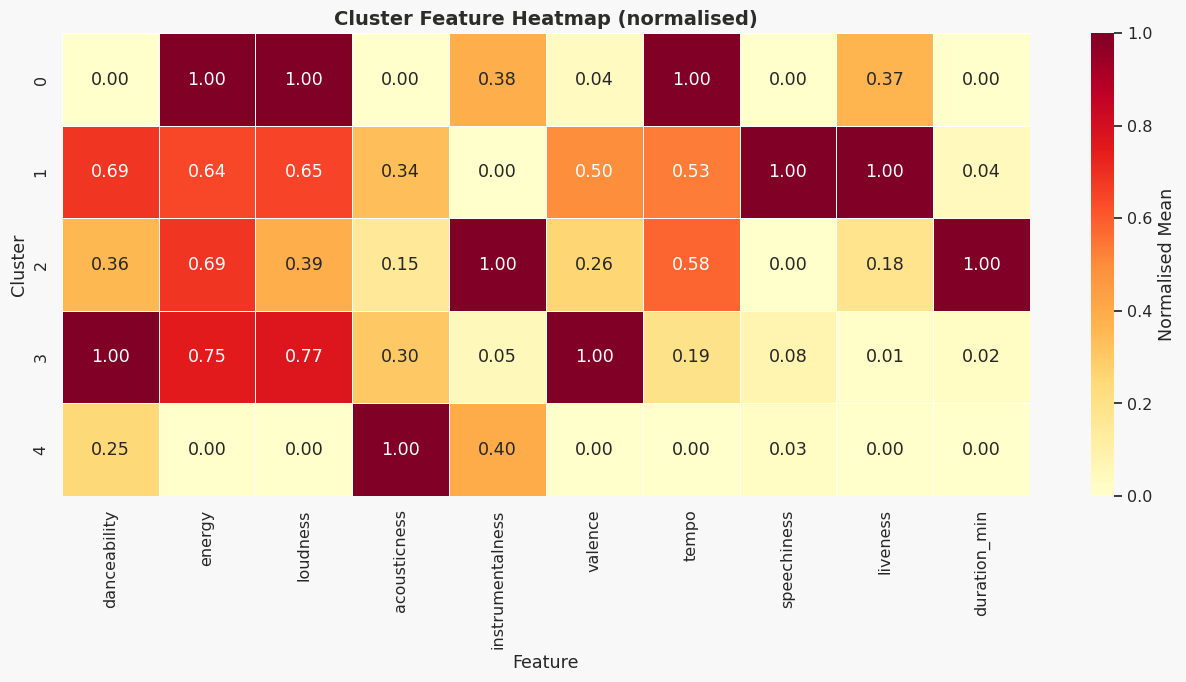

  Saved: cluster_heatmap.png



In [29]:
fig, ax = plt.subplots(figsize=(13, max(4, BEST_K + 2)))
sns.heatmap(norm_profiles, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Normalised Mean"})
ax.set_title("Cluster Feature Heatmap (normalised)", fontsize=14,
             fontweight="bold", color=ACCENT)
ax.set_xlabel("Feature")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.savefig("cluster_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()
print("  Saved: cluster_heatmap.png\n")

In [30]:
print("=" * 60)
print("CLUSTER INTERPRETATION SUMMARY")
print("=" * 60)
for cl in sorted(df_clean["cluster"].unique()):
    row = cluster_profiles.loc[cl]
    print(f"\n  Cluster {cl}  (n={int((df_clean['cluster']==cl).sum()):,})")
    print(f"    Energy      : {row['energy']:.2f}  | Valence    : {row['valence']:.2f}")
    print(f"    Danceability: {row['danceability']:.2f}  | Acousticness: {row['acousticness']:.2f}")
    print(f"    Instrumentalness: {row['instrumentalness']:.3f} | Speechiness: {row['speechiness']:.3f}")
    print(f"    Tempo       : {row['tempo']:.1f} BPM | Loudness: {row['loudness']:.1f} dB")

    label = []
    if row["energy"] > 0.7 and row["acousticness"] < 0.2:
        label.append("High-energy electronic/pop")
    if row["acousticness"] > 0.5:
        label.append("Acoustic/organic")
    if row["instrumentalness"] > 0.3:
        label.append("Instrumental-heavy")
    if row["speechiness"] > 0.15:
        label.append("Vocal/spoken-word")
    if row["valence"] > 0.7 and row["danceability"] > 0.7:
        label.append("Upbeat/danceable")
    if row["valence"] < 0.3 and row["energy"] < 0.5:
        label.append("Mellow/low-energy")
    if row["tempo"] > 125:
        label.append("Fast tempo")
    if row["tempo"] < 95:
        label.append("Slow tempo")
    if not label:
        label = ["Mixed/moderate profile"]
    print(f"    → Likely character: {' + '.join(label)}")

CLUSTER INTERPRETATION SUMMARY

  Cluster 0  (n=8,316)
    Energy      : 0.82  | Valence    : 0.38
    Danceability: 0.57  | Acousticness: 0.04
    Instrumentalness: 0.111 | Speechiness: 0.076
    Tempo       : 129.0 BPM | Loudness: -5.2 dB
    → Likely character: High-energy electronic/pop + Fast tempo

  Cluster 1  (n=2,751)
    Energy      : 0.69  | Valence    : 0.54
    Danceability: 0.69  | Acousticness: 0.18
    Instrumentalness: 0.024 | Speechiness: 0.326
    Tempo       : 122.0 BPM | Loudness: -6.8 dB
    → Likely character: Vocal/spoken-word

  Cluster 2  (n=2,639)
    Energy      : 0.71  | Valence    : 0.46
    Danceability: 0.63  | Acousticness: 0.10
    Instrumentalness: 0.250 | Speechiness: 0.077
    Tempo       : 122.8 BPM | Loudness: -8.0 dB
    → Likely character: High-energy electronic/pop

  Cluster 3  (n=9,226)
    Energy      : 0.73  | Valence    : 0.72
    Danceability: 0.75  | Acousticness: 0.16
    Instrumentalness: 0.034 | Speechiness: 0.096
    Tempo       : 11